In [120]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [121]:
df = pd.read_csv("data/medical_cost_prediction_dataset.csv")

print("Original Shape:", df.shape)

data_limit = 5000

df = df.head(data_limit)

print("After Limit:", df.shape)

df.head()

Original Shape: (5000, 20)
After Limit: (5000, 20)


,age,gender,bmi,smoker,diabetes,hypertension,heart_disease,asthma,physical_activity_level,daily_steps,sleep_hours,stress_level,doctor_visits_per_year,hospital_admissions,medication_count,insurance_type,insurance_coverage_pct,city_type,previous_year_cost,annual_medical_cost
0,69,Male,29.4,No,1,0,0,0,Medium,14825,4.4,8,1,0,4,Private,80,Semi-Urban,10885,2645.50
1,32,Female,22.9,No,1,0,0,0,Medium,3620,6.0,7,4,3,0,Government,64,Semi-Urban,18722,10959.70
2,89,Male,25.7,No,0,0,0,0,High,10578,4.5,7,2,0,3,NaN,0,Urban,4196,8409.80
3,78,Male,31.9,Yes,0,1,0,0,Low,6226,8.6,9,6,1,7,Government,70,Urban,11128,7996.62
4,38,Male,27.7,No,0,0,0,0,High,6253,5.7,3,6,0,6,Private,77,Urban,15110,3202.52


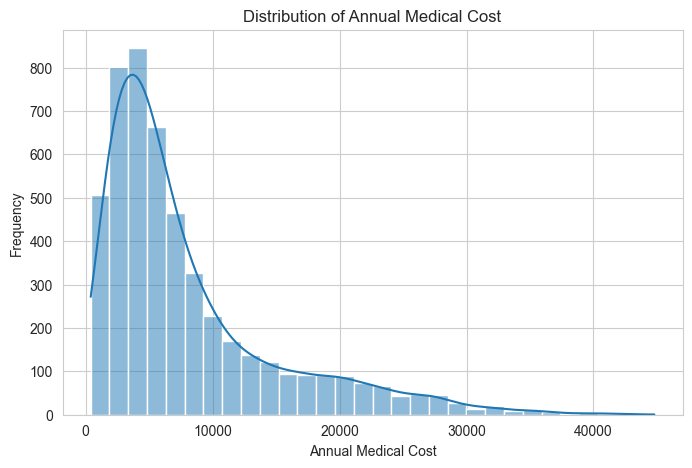

In [122]:
plt.figure(figsize=(8,5))

sns.histplot(df["annual_medical_cost"], bins=30, kde=True)

plt.title("Distribution of Annual Medical Cost")
plt.xlabel("Annual Medical Cost")
plt.ylabel("Frequency")

plt.show()

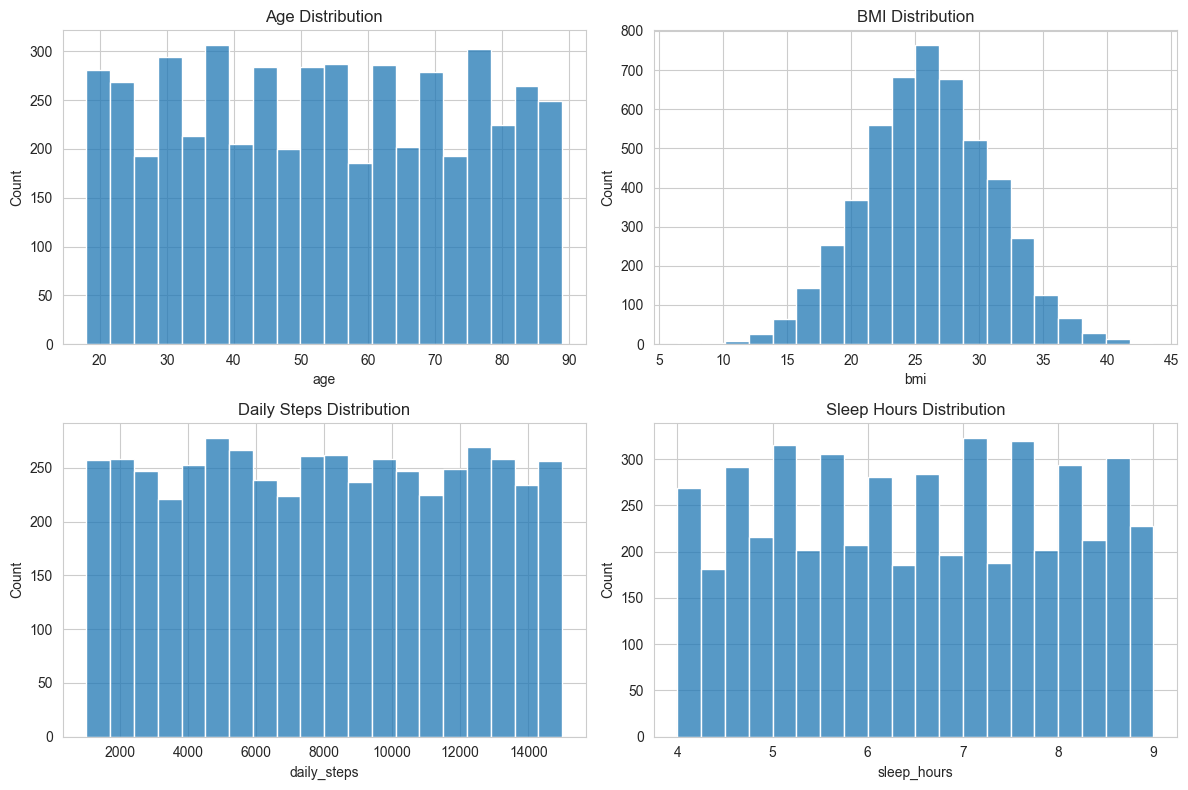

In [123]:
fig, axes = plt.subplots(2,2, figsize=(12,8))

sns.histplot(df["age"], bins=20, ax=axes[0,0])
axes[0,0].set_title("Age Distribution")

sns.histplot(df["bmi"], bins=20, ax=axes[0,1])
axes[0,1].set_title("BMI Distribution")

sns.histplot(df["daily_steps"], bins=20, ax=axes[1,0])
axes[1,0].set_title("Daily Steps Distribution")

sns.histplot(df["sleep_hours"], bins=20, ax=axes[1,1])
axes[1,1].set_title("Sleep Hours Distribution")

plt.tight_layout()
plt.show()

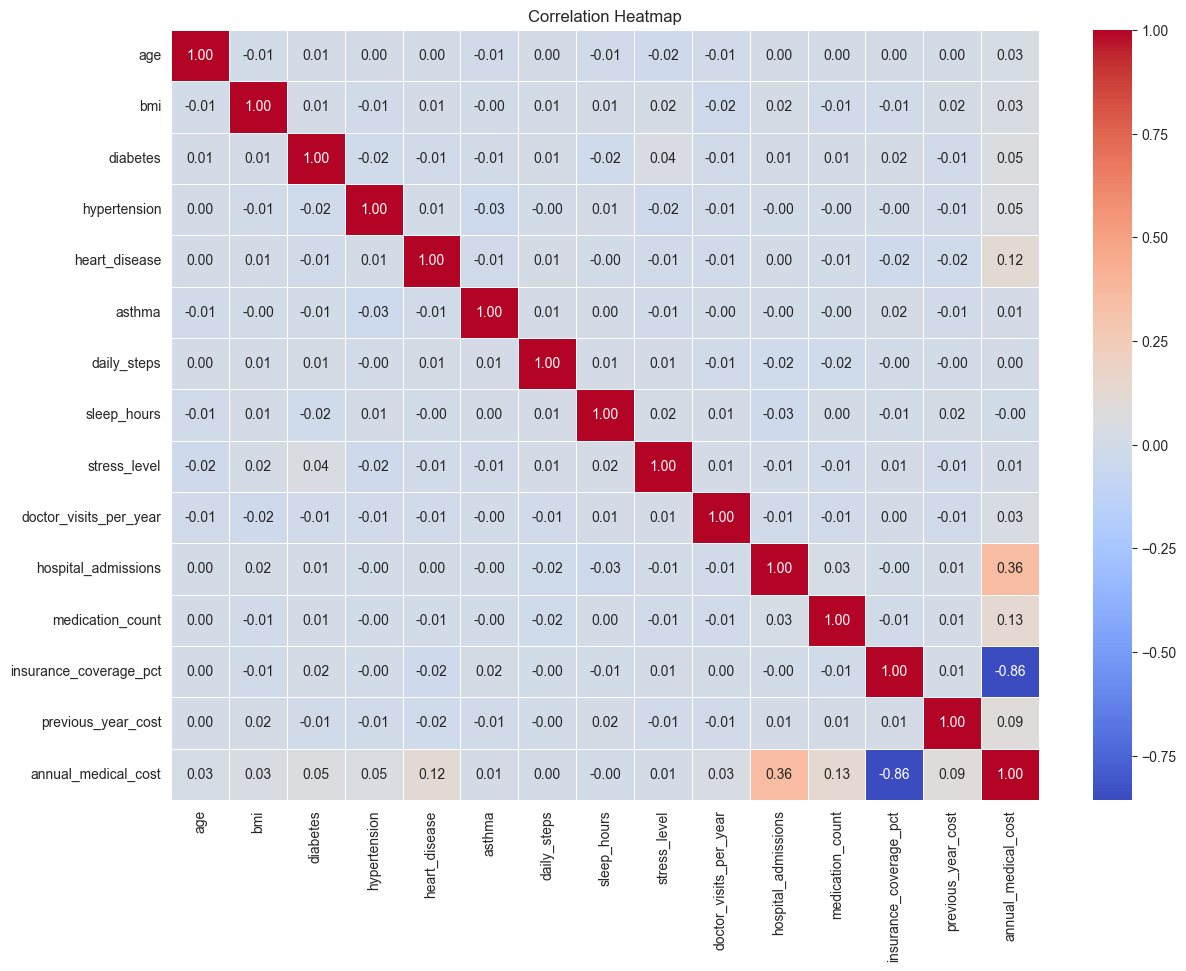

In [124]:
plt.figure(figsize=(14,10))

correlation = df.select_dtypes(include=["number"]).corr()

sns.heatmap(
    correlation,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

In [125]:
corr_target = df.select_dtypes(include=["number"]).corr()["annual_medical_cost"].sort_values(ascending=False)

print(corr_target)

annual_medical_cost       1.000000
hospital_admissions       0.355629
medication_count          0.133298
heart_disease             0.121740
previous_year_cost        0.089275
diabetes                  0.051429
hypertension              0.046926
doctor_visits_per_year    0.033748
bmi                       0.031030
age                       0.025330
stress_level              0.012596
asthma                    0.008869
daily_steps               0.001819
sleep_hours              -0.004788
insurance_coverage_pct   -0.856152
Name: annual_medical_cost, dtype: float64


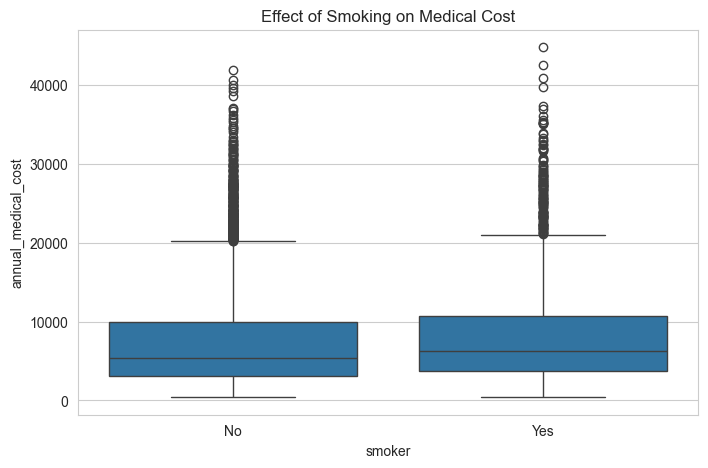

In [126]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["smoker"],
    y=df["annual_medical_cost"]
)

plt.title("Effect of Smoking on Medical Cost")

plt.show()

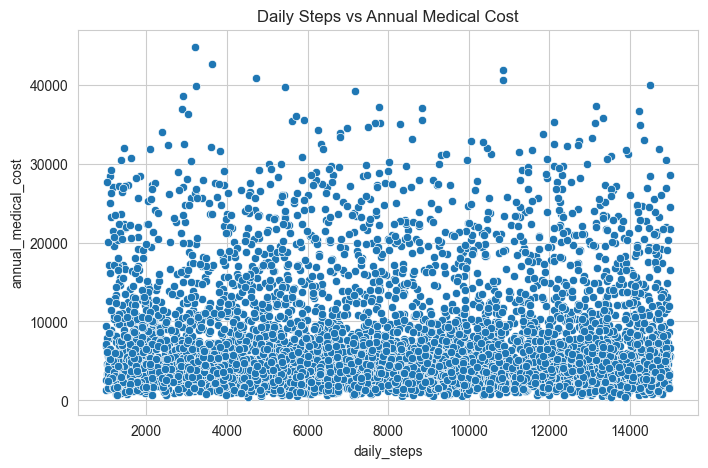

In [127]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["daily_steps"],
    y=df["annual_medical_cost"]
)

plt.title("Daily Steps vs Annual Medical Cost")

plt.show()

In [128]:
df.info()

# -----------------------------
# IDENTIFY NUMERICAL & CATEGORICAL FEATURES
# -----------------------------

numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

print("\nNumber of Numerical Features:", len(numerical_cols))
print("Number of Categorical Features:", len(categorical_cols))


df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      5000 non-null   int64  
 1   gender                   5000 non-null   object 
 2   bmi                      5000 non-null   float64
 3   smoker                   5000 non-null   object 
 4   diabetes                 5000 non-null   int64  
 5   hypertension             5000 non-null   int64  
 6   heart_disease            5000 non-null   int64  
 7   asthma                   5000 non-null   int64  
 8   physical_activity_level  5000 non-null   object 
 9   daily_steps              5000 non-null   int64  
 10  sleep_hours              5000 non-null   float64
 11  stress_level             5000 non-null   int64  
 12  doctor_visits_per_year   5000 non-null   int64  
 13  hospital_admissions      5000 non-null   int64  
 14  medication_count        

,age,bmi,diabetes,hypertension,heart_disease,asthma,daily_steps,sleep_hours,stress_level,doctor_visits_per_year,hospital_admissions,medication_count,insurance_coverage_pct,previous_year_cost,annual_medical_cost
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,53.299000,25.970820,0.207600,0.288000,0.14220,0.096400,7993.216800,6.488140,5.475400,4.030600,1.001000,3.509000,57.953000,10248.515400,8048.886894
std,20.646851,5.046651,0.405629,0.452876,0.34929,0.295169,4052.127069,1.443361,2.892312,2.010689,0.978566,2.292721,31.627742,5626.095015,7071.020228
min,18.000000,6.400000,0.000000,0.000000,0.00000,0.000000,1004.000000,4.000000,1.000000,0.000000,0.000000,0.000000,0.000000,500.000000,404.950000
25%,36.000000,22.600000,0.000000,0.000000,0.00000,0.000000,4545.000000,5.200000,3.000000,3.000000,0.000000,1.000000,53.000000,5342.750000,3241.977500
50%,53.000000,25.900000,0.000000,0.000000,0.00000,0.000000,7989.000000,6.500000,5.000000,4.000000,1.000000,3.000000,71.000000,10281.000000,5539.780000
75%,71.000000,29.400000,0.000000,1.000000,0.00000,0.000000,11532.250000,7.700000,8.000000,5.000000,2.000000,6.000000,79.000000,15034.500000,10094.097500
max,89.000000,43.600000,1.000000,1.000000,1.00000,1.000000,14999.000000,9.000000,10.000000,14.000000,6.000000,7.000000,94.000000,19996.000000,44792.100000


In [129]:
# -----------------------------
# OUTLIER REMOVAL (IQR METHOD)
# -----------------------------

numeric_cols = df.select_dtypes(include=["number"]).columns

for col in numeric_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print("Shape after outlier removal:", df.shape)

Shape after outlier removal: (2300, 20)


In [130]:
#Encoding categorical variables
df = pd.get_dummies(df, drop_first=True)
print("\nNumber of Numerical Features:", len(numerical_cols))
print("Number of Categorical Features:", len(categorical_cols))

df.head()


Number of Numerical Features: 15
Number of Categorical Features: 5


,age,bmi,diabetes,hypertension,heart_disease,asthma,daily_steps,sleep_hours,stress_level,doctor_visits_per_year,...,insurance_coverage_pct,previous_year_cost,annual_medical_cost,gender_Male,smoker_Yes,physical_activity_level_Low,physical_activity_level_Medium,insurance_type_Private,city_type_Semi-Urban,city_type_Urban
3,78,31.9,0,1,0,0,6226,8.6,9,6,...,70,11128,7996.62,True,True,True,False,False,False,True
4,38,27.7,0,0,0,0,6253,5.7,3,6,...,77,15110,3202.52,True,False,False,False,True,False,True
5,41,25.7,0,0,0,0,14720,7.7,10,5,...,89,18459,3072.16,True,False,False,True,True,False,True
6,20,23.0,0,0,0,0,14762,4.4,8,5,...,71,10047,4032.19,False,True,False,False,False,False,False
7,39,22.8,0,0,0,0,9726,4.6,6,3,...,66,13775,5302.81,False,False,True,False,False,False,False


In [131]:
X = df.drop(["annual_medical_cost", "previous_year_cost"], axis=1)

y = df["annual_medical_cost"]

In [132]:
splits = {
    "70:30": 0.30,
    "80:20": 0.20,
    "90:10": 0.10
}

In [133]:
results = []

for split_name, test_size in splits.items():

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=42
    )

    # -----------------------------
    # FEATURE SCALING (Standardization)
    # -----------------------------

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    X_train = pd.DataFrame(X_train, columns=X.columns)
    X_test = pd.DataFrame(X_test, columns=X.columns)

    # ---------------- XGBoost ----------------
    xgb_model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        random_state=42
    )

    xgb_model.fit(X_train, y_train)

    y_pred_xgb = xgb_model.predict(X_test)

    results.append({
        "Split": split_name,
        "Model": "XGBoost",
        "MAE": mean_absolute_error(y_test, y_pred_xgb),
        "MSE": mean_squared_error(y_test, y_pred_xgb),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_xgb)),
        "R2 Score": r2_score(y_test, y_pred_xgb)
    })


    # ---------------- LightGBM ----------------
    lgb_model = LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        random_state=42
    )

    lgb_model.fit(X_train, y_train)

    y_pred_lgb = lgb_model.predict(X_test)

    results.append({
        "Split": split_name,
        "Model": "LightGBM",
        "MAE": mean_absolute_error(y_test, y_pred_lgb),
        "MSE": mean_squared_error(y_test, y_pred_lgb),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_lgb)),
        "R2 Score": r2_score(y_test, y_pred_lgb)
    })


    # ---------------- CatBoost ----------------
    cat_model = CatBoostRegressor(
        iterations=200,
        learning_rate=0.1,
        depth=4,
        verbose=0,
        random_state=42
    )

    cat_model.fit(X_train, y_train)

    y_pred_cat = cat_model.predict(X_test)

    results.append({
        "Split": split_name,
        "Model": "CatBoost",
        "MAE": mean_absolute_error(y_test, y_pred_cat),
        "MSE": mean_squared_error(y_test, y_pred_cat),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_cat)),
        "R2 Score": r2_score(y_test, y_pred_cat)
    })

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000265 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 685
[LightGBM] [Info] Number of data points in the train set: 1610, number of used features: 17
[LightGBM] [Info] Start training from score 4530.412200
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000268 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 693
[LightGBM] [Info] Number of data points in the train set: 1840, number of used features: 17
[LightGBM] [Info] Start training from score 4516.127267
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000281 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 696
[LightGBM] [Info] Number of data points in the train set: 2070, number of used features: 17
[LightGBM] [Info] Start tra

In [134]:
comparison = pd.DataFrame(results)

comparison

,Split,Model,MAE,MSE,RMSE,R2 Score
0,70:30,XGBoost,456.604133,376563.163568,613.647426,0.940760
1,70:30,LightGBM,451.521394,353600.650914,594.643297,0.944373
2,70:30,CatBoost,418.219375,295068.344601,543.201937,0.953581
3,80:20,XGBoost,447.337900,355342.792601,596.106360,0.947829
4,80:20,LightGBM,436.936162,328242.783170,572.924762,0.951808
5,80:20,CatBoost,407.522464,283266.270995,532.227650,0.958411
6,90:10,XGBoost,465.794732,385288.666937,620.716253,0.945259
7,90:10,LightGBM,456.290550,368220.218557,606.811518,0.947684
8,90:10,CatBoost,434.082587,319168.408476,564.949917,0.954653


In [135]:
# -----------------------------
# INFERENCE (MANUAL SAMPLE)
# -----------------------------

# New Patient Data (with actual annual medical cost for comparison)
actual_annual_cost = 2500   

new_patient = pd.DataFrame({
    "age": [45],
    "bmi": [27],
    "diabetes": [0],
    "hypertension": [1],
    "heart_disease": [0],
    "asthma": [0],
    "daily_steps": [6500],
    "sleep_hours": [7],
    "stress_level": [5],
    "doctor_visits_per_year": [4],
    "hospital_admissions": [0],
    "medication_count": [2],
    "insurance_coverage_pct": [80],         # !!!
    "gender_Male": [1],                     # 1 = Male, 0 = Female
    "smoker_Yes": [1],                      # 1 = Yes, 0 = No   
    "physical_activity_level_Low": [0],
    "physical_activity_level_Medium": [1],
    "insurance_type_Private": [1],
    "city_type_Semi-Urban": [0],
    "city_type_Urban": [1]
})


new_patient = new_patient[X.columns]

# Model prediction
prediction = cat_model.predict(new_patient)[0]

# Counting difference
difference = abs(actual_annual_cost - prediction)

error_percent = (difference / actual_annual_cost) * 100

print("===== MANUAL INFERENCE =====")
print("AI Prediction:", round(prediction,2))
print("Real Annual Medical Cost:", actual_annual_cost)
print("Difference:", round(difference,2))
print("Error Percentage:", round(error_percent,2), "%")

===== MANUAL INFERENCE =====
AI Prediction: 2317.29
Real Annual Medical Cost: 2500
Difference: 182.71
Error Percentage: 7.31 %


In [136]:
# -----------------------------
# INFERENCE FROM DATASET
# -----------------------------

# Take 1 random data from the dataset
sample_data = df.sample(1)

# Take real cost
actual_cost = sample_data["annual_medical_cost"].values[0]

# Deletes target column
sample_features = sample_data.drop("annual_medical_cost", axis=1)

# Prediction
prediction = cat_model.predict(sample_features)[0]

difference = abs(actual_cost - prediction)

error_percent = (difference / actual_cost) * 100


print("===== DATASET INFERENCE =====")
print("The Chosen Index Data:", sample_data.index.values[0])
print()

print("AI Prediction:", round(prediction,2))
print("Real Annual Medical Cost:", round(actual_cost,2))
print("Difference:", round(difference,2))
print("Error Percentage:", round(error_percent,2), "%")

===== DATASET INFERENCE =====
The Chosen Index Data: 657

AI Prediction: 1691.38
Real Annual Medical Cost: 1862.18
Difference: 170.8
Error Percentage: 9.17 %
